In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import tg_vtss
importlib.reload(tg_vtss)
from sklearn.base import BaseEstimator

TAU_GQS = tg_vtss.TAU_GQS
GQS_FOLDS = tg_vtss.GQS_FOLDS
choose_tg_vtss_candidates = tg_vtss.choose_tg_vtss_candidates
print_tg_vtss_decision = tg_vtss.print_tg_vtss_decision
print_tg_vtss_summary = tg_vtss.print_tg_vtss_summary
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

mu = 1.0 

mu1 = np.array([mu, 0.0])

theta_star = np.array([mu/(mu**2 + 2), 0.0])

n1_values = np.array([10, 100, 200, 300, 400, 500]) 
imbalance_ratio = 20  
repetitions = 100

test_size_per_class = 5000

class BalancedLinearMSEEstimator(BaseEstimator):
    """No-intercept ridge least squares used only by TG-VTSS diagnostics."""
    def __init__(self, ridge=1e-6):
        self.ridge = ridge

    def fit(self, X, y, sample_weight=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        weight = np.ones(len(y), dtype=float) if sample_weight is None else np.asarray(sample_weight, dtype=float)
        XtWX = X.T @ (weight[:, None] * X)
        XtWy = X.T @ (weight * y)
        self.coef_ = np.linalg.solve(XtWX + self.ridge * np.eye(X.shape[1]), XtWy)
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.coef_


_original_tg_scores_and_hessians = tg_vtss._scores_and_hessians
def _mse_scores_and_hessians(model, X, y):
    """Exact per-observation gradient and Hessian for squared loss."""
    if not isinstance(model, BalancedLinearMSEEstimator):
        return _original_tg_scores_and_hessians(model, X, y)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    residual = model.predict(X) - y
    scores = 2.0 * residual[:, None] * X
    hessians = 2.0 * X[:, :, None] * X[:, None, :]
    return scores, hessians


tg_vtss._scores_and_hessians = _mse_scores_and_hessians

def sample_synthetic_aligned(n_syn, n1, mu1):
    if n_syn <= 0:
        return np.empty((0, 2))
    c = 1
    mu_syn = (1.0 - c / np.sqrt(np.log(n1))) * mu1
    return np.random.randn(n_syn, 2) + mu_syn


def compute_theta_hat_from_stats(XtX, Xty, ridge=1e-6):
    d = XtX.shape[0]
    return np.linalg.solve(XtX + ridge * np.eye(d), Xty)


def balanced_mse(theta, X, y):
    X0 = X[y == 0]
    X1 = X[y == 1]
    mse0 = np.mean((X0 @ theta - 0.0) ** 2)
    mse1 = np.mean((X1 @ theta - 1.0) ** 2)
    return 0.5 * (mse0 + mse1)


def compute_balanced_risk(theta, mu1):
    term1 = theta @ theta
    term2 = 0.5 * (theta @ mu1 - 1.0) ** 2
    return term1 + term2


def compute_excess_risk(theta, mu1):
    return compute_balanced_risk(theta, mu1) - compute_balanced_risk(theta_star, mu1)


def precompute_train_stats(X0_tr, X1_tr):
    X_base = np.vstack([X0_tr, X1_tr])
    y_base = np.hstack([np.zeros(len(X0_tr)), np.ones(len(X1_tr))])
    XtX_base = X_base.T @ X_base
    Xty_base = X_base.T @ y_base
    return XtX_base, Xty_base


def precompute_syn_cumsums(X_syn_pool):
    if len(X_syn_pool) == 0:
        return None, None
    syn_Xty_cum = np.cumsum(X_syn_pool, axis=0)  
    syn_outer = np.einsum('ni,nj->nij', X_syn_pool, X_syn_pool)  
    syn_XtX_cum = np.cumsum(syn_outer, axis=0)  
    return syn_XtX_cum, syn_Xty_cum


def theta_hat_with_k_syn(XtX_base, Xty_base, syn_XtX_cum, syn_Xty_cum, k, ridge=1e-6):
    if k <= 0:
        return compute_theta_hat_from_stats(XtX_base, Xty_base, ridge=ridge)
    XtX = XtX_base + syn_XtX_cum[k - 1]
    Xty = Xty_base + syn_Xty_cum[k - 1]
    return compute_theta_hat_from_stats(XtX, Xty, ridge=ridge)


def validation_tune_synthetic_size(X0_tr, X1_tr, X_val, y_val, gamma_grid, mu1, n1, ridge=1e-6):
    n0 = len(X0_tr)
    g = n0 - n1

    gamma_grid = np.asarray(gamma_grid, dtype=float)
    n_syn_grid = np.maximum(0, np.rint(gamma_grid * g).astype(int))

    max_need = int(n_syn_grid.max())
    X_syn_pool = sample_synthetic_aligned(max_need, n1=n1, mu1=mu1)

    XtX_base, Xty_base = precompute_train_stats(X0_tr, X1_tr)
    syn_XtX_cum, syn_Xty_cum = precompute_syn_cumsums(X_syn_pool)

    best_val = np.inf
    best_gamma = None
    best_k = None
    best_theta = None
    all_candidates = []

    for gamma, k in zip(gamma_grid, n_syn_grid):
        theta = theta_hat_with_k_syn(XtX_base, Xty_base, syn_XtX_cum, syn_Xty_cum, k, ridge=ridge)
        val_loss = balanced_mse(theta, X_val, y_val)

        all_candidates.append((float(gamma), int(k), float(val_loss)))
        if val_loss < best_val:
            best_val = val_loss
            best_gamma = float(gamma)
            best_k = int(k)
            best_theta = theta

    best = {
        'gamma_star': best_gamma,
        'n_syn_star': best_k,
        'theta_star': best_theta,
        'val_loss_star': float(best_val),
        'all_candidates': all_candidates
    }

    cache = {
        'g': int(g),
        'XtX_base': XtX_base,
        'Xty_base': Xty_base,
        'syn_XtX_cum': syn_XtX_cum,
        'syn_Xty_cum': syn_Xty_cum,
        'X_syn_pool': X_syn_pool,
        'gamma_grid': gamma_grid,
        'n_syn_grid': n_syn_grid
    }

    return best, cache


def stratified_kfold_indices(y, n_splits=3, seed=42):
    y = np.asarray(y)
    rng = np.random.RandomState(seed)
    classes = np.unique(y)
    idx_by_class = {c: np.where(y == c)[0] for c in classes}
    for c in classes:
        rng.shuffle(idx_by_class[c])

    folds = [[] for _ in range(n_splits)]
    for c in classes:
        splits = np.array_split(idx_by_class[c], n_splits)
        for i in range(n_splits):
            folds[i].extend(splits[i].tolist())

    fold_indices = [np.array(f, dtype=int) for f in folds]
    all_idx = np.arange(len(y))
    out = []
    for i in range(n_splits):
        val_idx = np.sort(fold_indices[i])
        train_mask = np.ones(len(y), dtype=bool)
        train_mask[val_idx] = False
        train_idx = all_idx[train_mask]
        out.append((train_idx, val_idx))
    return out


def cv_tune_synthetic_size(X, y, gamma_grid, mu1, n_splits=5, seed=42, ridge=1e-6):
    gamma_grid = np.asarray(gamma_grid, dtype=float)
    cv_losses = np.zeros(len(gamma_grid), dtype=float)

    for tr_idx, va_idx in stratified_kfold_indices(y, n_splits=n_splits, seed=seed):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        X0_tr = X_tr[y_tr == 0]
        X1_tr = X_tr[y_tr == 1]

        best, _ = validation_tune_synthetic_size(
            X0_tr=X0_tr, X1_tr=X1_tr,
            X_val=X_va, y_val=y_va,
            gamma_grid=gamma_grid,
            mu1=mu1, n1=len(X1_tr),
            ridge=ridge
        )

        cv_losses += np.array([cand[2] for cand in best['all_candidates']], dtype=float)

    cv_losses /= float(n_splits)
    best_idx = int(np.argmin(cv_losses))

    return {
        'gamma_star': float(gamma_grid[best_idx]),
        'cv_loss_star': float(cv_losses[best_idx]),
        'cv_losses': cv_losses
    }


def fit_theta_with_gamma(X0_tr, X1_tr, gamma, mu1, ridge=1e-6):
    n0 = len(X0_tr)
    n1 = len(X1_tr)
    g = n0 - n1
    k = int(np.maximum(0, np.rint(float(gamma) * g)))

    X_syn_pool = sample_synthetic_aligned(k, n1=n1, mu1=mu1)
    XtX_base, Xty_base = precompute_train_stats(X0_tr, X1_tr)
    syn_XtX_cum, syn_Xty_cum = precompute_syn_cumsums(X_syn_pool)

    theta = theta_hat_with_k_syn(XtX_base, Xty_base, syn_XtX_cum, syn_Xty_cum, k=k, ridge=ridge)
    return theta

metrics_valtuned = {'excess_risk': [], 'param_error': []}
metrics_balanced = {'excess_risk': [], 'param_error': []}
pct = {'excess_risk': [], 'param_error': []}
tg_decisions = []


for n1 in n1_values:
    n0 = int(n1 * imbalance_ratio)
    g = n0 - n1

    temp_tuned = {'excess_risk': [], 'param_error': []}
    temp_bal = {'excess_risk': [], 'param_error': []}
    temp_pct = {'excess_risk': [], 'param_error': []}

    for rep in range(repetitions):
        X0_tv = np.random.randn(n0, 2)  
        X1_tv = np.random.randn(n1, 2) + mu1 

        X_tv = np.vstack([X0_tv, X1_tv])
        y_tv = np.hstack([np.zeros(len(X0_tv)), np.ones(len(X1_tv))])

        def diagnostic_aligned_generator(X_real, y_real, n_synthetic, generator_seed):
            n1_real = int(np.sum(y_real == 1))
            if n_synthetic <= 0:
                return np.empty((0, X_real.shape[1]))
            c = 1
            mu_syn = (1.0 - c / np.sqrt(np.log(n1_real))) * mu1
            diagnostic_rng = np.random.RandomState(generator_seed)
            return diagnostic_rng.randn(n_synthetic, X_real.shape[1]) + mu_syn

        diagnostic_estimator = BalancedLinearMSEEstimator(ridge=1e-6)
        tg_decision = choose_tg_vtss_candidates(
            X_tv, y_tv, diagnostic_estimator, diagnostic_aligned_generator,
            tau_gqs=TAU_GQS, folds=GQS_FOLDS, seed=42,
        )
        tg_decisions.append(tg_decision)
        print_tg_vtss_decision(
            f"n1={n1}, rep={rep}", tg_decision,
            tau_gqs=TAU_GQS, random_seed=42,
        )
        tg_gamma_grid = np.asarray(tg_decision.candidate_sizes, dtype=float) / g

        cv_best = cv_tune_synthetic_size(
            X=X_tv, y=y_tv,
            gamma_grid=tg_gamma_grid,
            mu1=mu1,
            n_splits=5,
            seed=42
        )
        gamma_star = cv_best['gamma_star']

        theta_tuned = fit_theta_with_gamma(X0_tv, X1_tv, gamma_star, mu1=mu1)

        theta_bal = fit_theta_with_gamma(X0_tv, X1_tv, 1.0, mu1=mu1)

        temp_tuned['excess_risk'].append(compute_excess_risk(theta_tuned, mu1))
        temp_tuned['param_error'].append(np.linalg.norm(theta_tuned - theta_star))

        temp_bal['excess_risk'].append(compute_excess_risk(theta_bal, mu1))
        temp_bal['param_error'].append(np.linalg.norm(theta_bal - theta_star))

        temp_pct['excess_risk'].append(abs(compute_excess_risk(theta_bal, mu1)-compute_excess_risk(theta_tuned, mu1))/compute_excess_risk(theta_bal, mu1))
        temp_pct['param_error'].append(abs(np.linalg.norm(theta_bal - theta_star)-np.linalg.norm(theta_tuned - theta_star))/np.linalg.norm(theta_bal - theta_star))

    for metric in ['excess_risk', 'param_error']:
        tuned_vals = np.array(temp_tuned[metric])
        bal_vals   = np.array(temp_bal[metric])
        pct_vals   = np.array(temp_pct[metric])

        metrics_valtuned[metric].append({'mean': float(np.mean(tuned_vals)),
                                         'std': float(np.std(tuned_vals)),
                                         'ci_low': float(np.percentile(tuned_vals, 2.5)),
                                         'ci_high': float(np.percentile(tuned_vals, 97.5))})
        metrics_balanced[metric].append({'mean': float(np.mean(bal_vals)),
                                         'std': float(np.std(bal_vals)),
                                         'ci_low': float(np.percentile(bal_vals, 2.5)),
                                         'ci_high': float(np.percentile(bal_vals, 97.5))})
        pct[metric].append({'mean': float(np.mean(pct_vals)),
                             'std': float(np.std(pct_vals)),
                             'ci_low': float(np.percentile(pct_vals, 2.5)),
                             'ci_high': float(np.percentile(pct_vals, 97.5))})

    print(f"Completed n1 = {n1}: "
          f"Val-tuned excess risk = {metrics_valtuned['excess_risk'][-1]['mean']:.4g}, "
          f"Balanced excess risk = {metrics_balanced['excess_risk'][-1]['mean']:.4g}")

print_tg_vtss_summary(tg_decisions)


run=n1=10, rep=0 | random_seed=42 | regime=local asymmetry | generator=realistic generator | T_sym=24.5958 (cutoff=5.99146) | GQS=7.87567 (tau_GQS=10) | ||g_phi||=1.21315, ||g_psi||=0.644507, cos=0.952262, denominator=-0.0118077 | theory_target=not used | around_balance=[152, 162, 171, 181, 190, 200, 209, 219, 228] | around_theory=[] | candidates=[152, 162, 171, 181, 190, 200, 209, 219, 228]
run=n1=10, rep=1 | random_seed=42 | regime=local asymmetry | generator=biased generator | T_sym=140.609 (cutoff=5.99146) | GQS=24.6244 (tau_GQS=10) | ||g_phi||=1.68894, ||g_psi||=1.14097, cos=0.999658, denominator=nan | theory_target=not used | around_balance=[0, 10, 19, 29, 38, 48, 57, 66, 76, 86, 95, 105, 114, 124, 133, 142, 152, 162, 171, 180, 190, 200, 209, 219, 228, 238, 247, 256, 266, 276, 285, 294, 304, 314, 323, 332, 342, 352, 361, 371, 380] | around_theory=[] | candidates=[0, 10, 19, 29, 38, 48, 57, 66, 76, 86, 95, 105, 114, 124, 133, 142, 152, 162, 171, 180, 190, 200, 209, 219, 228, 238, 

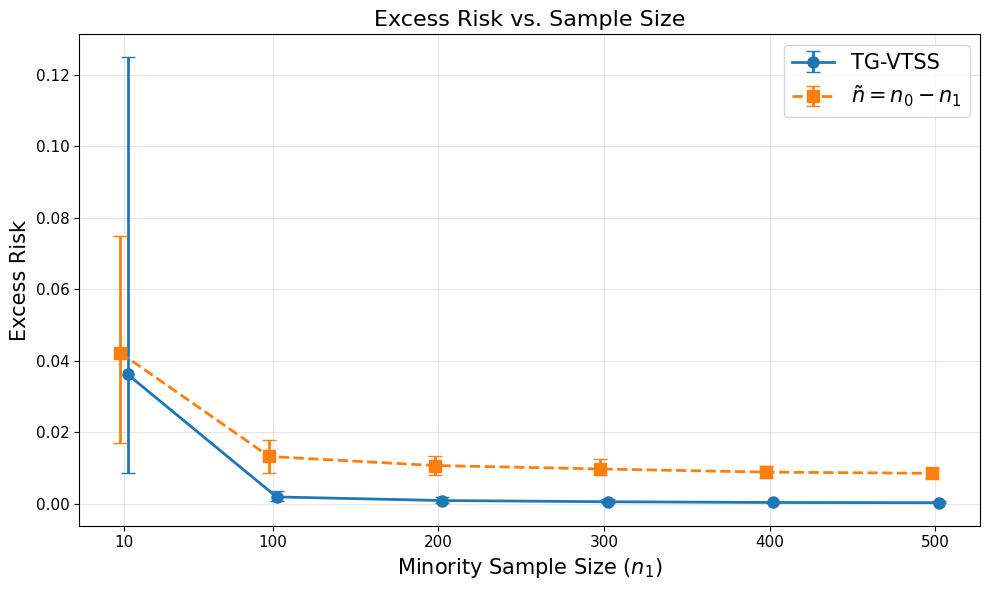

In [2]:
n1_array = n1_values
tuned_means = {m: [x['mean'] for x in metrics_valtuned[m]] for m in metrics_valtuned}
balanced_means = {m: [x['mean'] for x in metrics_balanced[m]] for m in metrics_balanced}

tuned_ci_low  = {m: [x['ci_low']  for x in metrics_valtuned[m]] for m in metrics_valtuned}
tuned_ci_high = {m: [x['ci_high'] for x in metrics_valtuned[m]] for m in metrics_valtuned}
balanced_ci_low  = {m: [x['ci_low']  for x in metrics_balanced[m]] for m in metrics_balanced}
balanced_ci_high = {m: [x['ci_high'] for x in metrics_balanced[m]] for m in metrics_balanced}

tuned_mean_excess = np.array(tuned_means['excess_risk'], dtype=float)
tuned_low_excess  = np.array(tuned_ci_low['excess_risk'], dtype=float)
tuned_high_excess = np.array(tuned_ci_high['excess_risk'], dtype=float)
tuned_yerr_excess = np.vstack([tuned_mean_excess - tuned_low_excess,
                               tuned_high_excess - tuned_mean_excess])

bal_mean_excess = np.array(balanced_means['excess_risk'], dtype=float)
bal_low_excess  = np.array(balanced_ci_low['excess_risk'], dtype=float)
bal_high_excess = np.array(balanced_ci_high['excess_risk'], dtype=float)
balanced_yerr_excess = np.vstack([bal_mean_excess - bal_low_excess,
                                  bal_high_excess - bal_mean_excess])

x = np.array(n1_array, dtype=float)
min_step = np.min(np.diff(np.sort(x)))
dx = 0.05 * min_step
x_tuned = x + dx/2
x_bal   = x - dx/2

plt.figure(figsize=(10, 6))
plt.errorbar(x_tuned, tuned_mean_excess, yerr=tuned_yerr_excess,
             fmt='o-', capsize=5, label='TG-VTSS', linewidth=2, markersize=8)
plt.errorbar(x_bal, bal_mean_excess, yerr=balanced_yerr_excess,
             fmt='s--', capsize=5, label='$\\~n=n_0-n_1$', linewidth=2, markersize=8)

plt.xlabel('Minority Sample Size ($n_1$)', fontsize=15)
plt.ylabel('Excess Risk', fontsize=15)
plt.title('Excess Risk vs. Sample Size', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=15)
plt.xticks(x, [str(int(v)) for v in x], fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

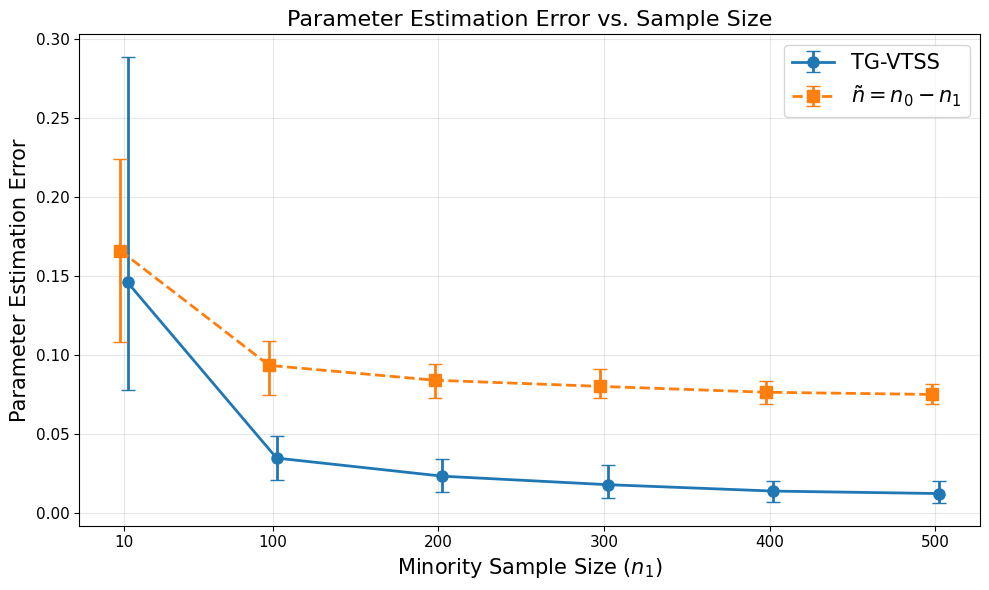

In [3]:
plt.figure(figsize=(10, 6))

tuned_yerr_param = np.vstack([
    np.array(tuned_means['param_error']) - np.array(tuned_ci_low['param_error']),
    np.array(tuned_ci_high['param_error']) - np.array(tuned_means['param_error'])
])
balanced_yerr_param = np.vstack([
    np.array(balanced_means['param_error']) - np.array(balanced_ci_low['param_error']),
    np.array(balanced_ci_high['param_error']) - np.array(balanced_means['param_error'])
])

x = np.array(n1_array, dtype=float)
min_step = np.min(np.diff(np.sort(x)))
dx = 0.05 * min_step 

x_tuned = x + dx/2   
x_bal   = x - dx/2   

plt.errorbar(x_tuned, tuned_means['param_error'], yerr=tuned_yerr_param,
             fmt='o-', capsize=5, label='TG-VTSS', linewidth=2, markersize=8)
plt.errorbar(x_bal, balanced_means['param_error'], yerr=balanced_yerr_param,
             fmt='s--', capsize=5, label='$\\~n=n_0-n_1$', linewidth=2, markersize=8)

plt.xlabel('Minority Sample Size ($n_1$)', fontsize=15)
plt.ylabel('Parameter Estimation Error', fontsize=15)
plt.title('Parameter Estimation Error vs. Sample Size', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=15)

plt.xticks(x, [str(int(v)) for v in x], fontsize=11)

plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()